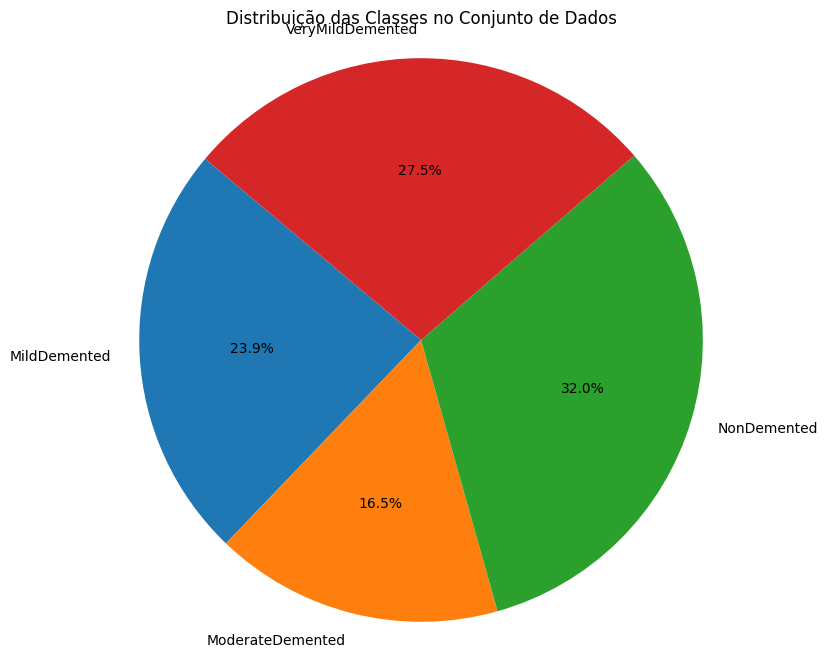

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import sklearn.utils as su
import cv2

augmented_image_path = './OriginalDataset'
categories = ['MildDemented','ModerateDemented','NonDemented','VeryMildDemented']

images_list = []
classes = []

for category in categories:
    image_path = os.path.join(augmented_image_path, category)
    for images in os.listdir(image_path):
        image = cv2.imread(os.path.join(image_path, images))
        image = cv2.resize(image, (128,128))
        image = np.expand_dims(image,axis=-1)
        image = image /255
        images_list.append(image)
        classes.append(category)
        
images_list = np.array(images_list)
classes = np.array(classes)

images_list, classes = su.shuffle(images_list, classes, random_state=101)

unique_classes, class_counts = np.unique(classes, return_counts=True)

plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=unique_classes, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição das Classes no Conjunto de Dados')
plt.axis('equal')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

import tensorflow as tf
x_train, x_test, y_train, y_test = train_test_split(images_list, classes, random_state=101, test_size=0.3)
 
y_new_train = []
for i in y_train:
    y_new_train.append(categories.index(i))
y_train = y_new_train
y_train = tf.keras.utils.to_categorical(y_train)

y_new_test = []
for i in y_test:
    y_new_test.append(categories.index(i))
y_test = y_new_test
y_test = tf.keras.utils.to_categorical(y_test)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
import tensorflow as tf

model = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(32, 3, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, 3, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(64, 3, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(128, 3, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(128, 3, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(128, 3, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(256, 3, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dense(512, activation='relu', kernel_regularizer=l2(0.0001)),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=l2(0.0001)),
    Dropout(0.4),
    Dense(4, activation='softmax')
])
model.summary()

from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(classes), y=classes)
class_weights = dict(enumerate(class_weights))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), metrics=['accuracy'], loss='categorical_crossentropy')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lpt = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5)

history = model.fit(x_train,y_train, epochs=25, class_weight=class_weights, validation_data=(x_test,y_test), callbacks=[early_stop, reduce_lpt], verbose=1)

loss, accuracy = model.evaluate(x_test, y_test)

print(f'Acurácia: {accuracy}')
print(f'Perda: {loss}')

C:\Users\anton\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 59, 59, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 59, 59, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 27, 27, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 23, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 9, 9, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             

 Total params: 2,963,108 (11.30 MB)

 Trainable params: 2,961,444 (11.30 MB)

 Non-trainable params: 1,664 (6.50 KB)

Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.4136 - loss: 1.9445 - val_accuracy: 0.2358 - val_loss: 3.9259 - learning_rate: 5.0000e-04
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.5800 - loss: 1.0417 - val_accuracy: 0.2917 - val_loss: 3.4870 - learning_rate: 5.0000e-04
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.6615 - loss: 0.8658 - val_accuracy: 0.3956 - val_loss: 2.0015 - learning_rate: 5.0000e-04
Epoch 4/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.7130 - loss: 0.7709 - val_accuracy: 0.7606 - val_loss: 0.7314 - learning_rate: 5.0000e-04
Epoch 5/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.7674 - loss: 0.6619 - val_accuracy: 0.7872 - val_loss: 0.7065 - learning_rate: 5.0000e-04
Epoch 6/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.8321 - loss: 0.5440 - val_accuracy: 0.5911 - val_loss: 1.3886 - learning_rate: 5.0000e-04
Epoch 7/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - acc

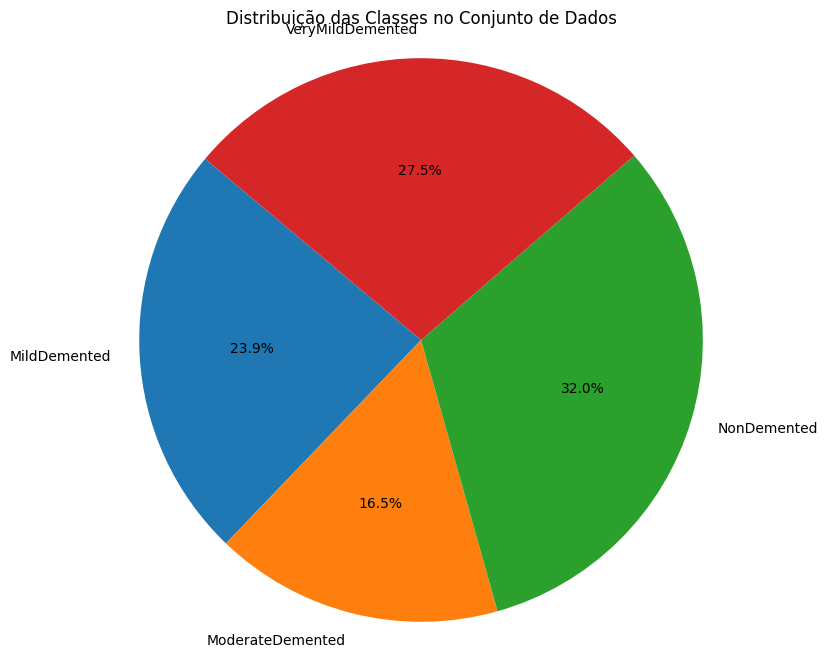

In [8]:
import os
import matplotlib.pyplot as plt
import numpy as np
import sklearn.utils as su
import cv2

augmented_image_path = './OriginalDataset'
categories = ['MildDemented','ModerateDemented','NonDemented','VeryMildDemented']

images_list = []
classes = []

for category in categories:
    image_path = os.path.join(augmented_image_path, category)
    for images in os.listdir(image_path):
        image = cv2.imread(os.path.join(image_path, images))
        image = cv2.resize(image, (128,128))
        image = np.expand_dims(image,axis=-1)
        image = image /255
        images_list.append(image)
        classes.append(category)
        
images_list = np.array(images_list)
classes = np.array(classes)

images_list, classes = su.shuffle(images_list, classes, random_state=101)

unique_classes, class_counts = np.unique(classes, return_counts=True)

plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=unique_classes, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição das Classes no Conjunto de Dados')
plt.axis('equal')
plt.show()

model.save('cnn_model.h5')

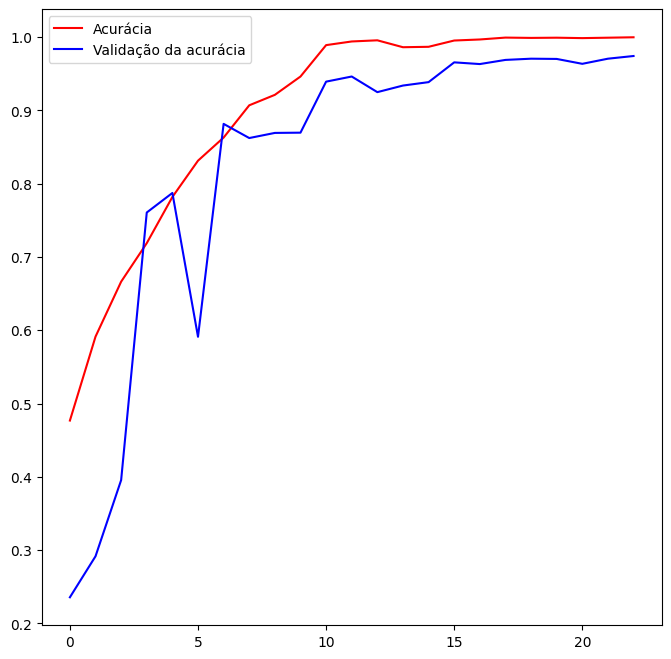

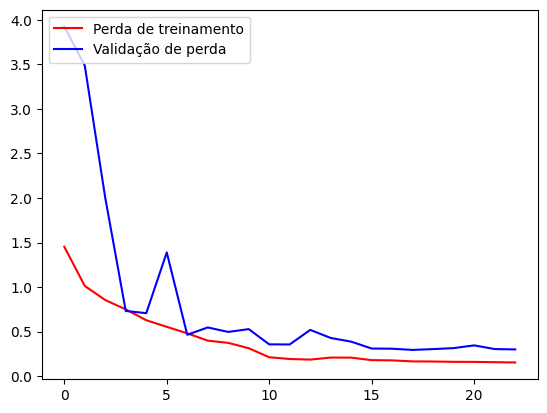

In [5]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.figure(figsize=(8,8))
plt.plot(epochs,acc, 'r', label='Acurácia')
plt.plot(epochs,val_acc, 'b', label='Validação da acurácia')
plt.legend(loc='upper left')
plt.show()

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_loss = range(len(loss))

plt.plot(epochs_loss, loss, 'r', label='Perda de treinamento')
plt.plot(epochs_loss, val_loss,'b', label='Validação de perda')
plt.legend(loc='upper left')
plt.show()